In [162]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.metrics.pairwise import cosine_similarity

**Task 1.2**

In [163]:
# Task 1.2 functions
def dot_product(v1,v2):
    dot_sum = 0
    for a, b in zip(v1,v2):
        dot_sum += a*b
    return dot_sum

def mag_sum(v1):
    mag_sum = 0
    for a in v1:
        mag_sum += a**2
    return math.sqrt(mag_sum)

def cosine_similarity_two(v1,v2):
    cos_similarity = (dot_product(v1,v2) / (mag_sum(v1)*mag_sum(v2)))
    return cos_similarity

In [164]:
# Task 1.2 output
v1 = [3,4]
v2 = [-3,-4]
cs_test = cosine_similarity_two(v1, v2)
cs_test

-1.0

In [165]:
# Task 1.2 validation
numpy_dot = np.dot(v1,v2)

numpy_mag1 = np.linalg.norm(v1)
numpy_mag2 = np.linalg.norm(v2)

numpy_cs = numpy_dot / (numpy_mag1*numpy_mag2)
numpy_cs

np.float64(-1.0)

**Task 1.3**

In [166]:
# Task 1.3
df = pd.read_csv(r"D:\SapphireWork\data\raw\dirty_cafe_sales.csv")
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [167]:
df.isna().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [168]:
# checking info
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


In [ ]:
# data type change krrahy ham, from str (object) to suitable while removing things
df["Transaction ID"] = df["Transaction ID"].astype(str).str.strip().astype("string")
df["Item"] = df["Item"].astype(str).str.strip().astype("string")
df["Payment Method"] = df["Payment Method"].astype(str).str.strip().astype("category")
df["Location"] = df["Location"].astype(str).str.strip().astype("string")

for col in ["Quantity", "Price Per Unit", "Total Spent"]:
    df[col] = df[col].astype(str).str.replace(r"[$,\s]", "", regex=True)

df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce").astype("Int64")
df["Price Per Unit"] = pd.to_numeric(df["Price Per Unit"], errors="coerce")
df["Total Spent"] = pd.to_numeric(df["Total Spent"], errors="coerce")

df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")

In [170]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  string        
 1   Item              9667 non-null   string        
 2   Quantity          9521 non-null   Int64         
 3   Price Per Unit    9467 non-null   float64       
 4   Total Spent       9498 non-null   float64       
 5   Payment Method    7421 non-null   category      
 6   Location          6735 non-null   string        
 7   Transaction Date  9540 non-null   datetime64[us]
dtypes: Int64(1), category(1), datetime64[us](1), float64(2), string(3)
memory usage: 566.6 KB


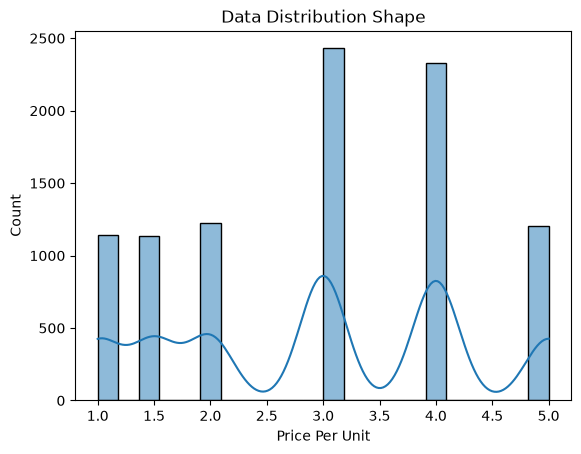

In [171]:
sns.histplot(df["Price Per Unit"].dropna(), kde=True)
plt.title("Data Distribution Shape")
plt.show()

In [172]:
print(df["Price Per Unit"].value_counts(bins=5).sort_index())

(0.995, 1.8]    2276
(1.8, 2.6]      1227
(2.6, 3.4]      2429
(3.4, 4.2]      2331
(4.2, 5.0]      1204
Name: count, dtype: int64


In [ ]:
# transform, group ky hisaab se koi bhi aggregate function lagaskta 
df["Price Per Unit"] = df["Price Per Unit"].fillna(
        df.groupby("Item")["Price Per Unit"].transform("median")
)
# median
df["Price Per Unit"] = df["Price Per Unit"].fillna(
    df["Price Per Unit"].median()
)

df["Quantity"] = df["Quantity"].fillna(
    df.groupby("Item")["Quantity"].transform("median")
)

df["Quantity"] = df["Quantity"].fillna(1)

# new total spent ka column
df["Total Spent"] = df["Total Spent"].fillna(
    df["Quantity"] * df["Price Per Unit"]
)

# fill missing text
df["Location"] = df["Location"].fillna("Unknown")
df["Item"] = df["Item"].fillna("Unknown")

# add 'Unknown' as category for Nan values
df["Payment Method"] = df["Payment Method"].cat.add_categories("Unknown")
df["Payment Method"] = df["Payment Method"].fillna("Unknown")

import pandas as pd

# error aur unknown ko 'Unknown' krdia
df["Location"] = df["Location"].astype(str).str.strip().str.upper()
df["Location"] = df["Location"].replace(["UNKNOWN", "ERROR"], "Unknown")
df["Location"] = df["Location"].astype("string")

df["Payment Method"] = df["Payment Method"].astype(str).str.strip().str.upper()
df["Payment Method"] = df["Payment Method"].replace(["UNKNOWN", "ERROR"], "Unknown")

df["Payment Method"] = df["Payment Method"].astype("category")


df = df.sort_values(by="Transaction Date")
df["Transaction Date"] = df["Transaction Date"].ffill().bfill()

In [174]:
df.isna().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [175]:
df.info()

<class 'pandas.DataFrame'>
Index: 10000 entries, 8015 to 9988
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  string        
 1   Item              10000 non-null  string        
 2   Quantity          10000 non-null  Int64         
 3   Price Per Unit    10000 non-null  float64       
 4   Total Spent       10000 non-null  float64       
 5   Payment Method    10000 non-null  category      
 6   Location          10000 non-null  string        
 7   Transaction Date  10000 non-null  datetime64[us]
dtypes: Int64(1), category(1), datetime64[us](1), float64(2), string(3)
memory usage: 644.6 KB


In [176]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
8015,TXN_4801947,Juice,1,3.0,3.0,DIGITAL WALLET,TAKEAWAY,2023-01-01
9063,TXN_9161256,Smoothie,2,4.0,8.0,DIGITAL WALLET,IN-STORE,2023-01-01
7309,TXN_6093955,Tea,5,1.5,7.5,Unknown,TAKEAWAY,2023-01-01
1425,TXN_8842223,Sandwich,5,4.0,20.0,DIGITAL WALLET,IN-STORE,2023-01-01
1777,TXN_7367474,Juice,5,3.0,15.0,DIGITAL WALLET,TAKEAWAY,2023-01-01
...,...,...,...,...,...,...,...,...
9933,TXN_9460419,Cake,1,3.0,3.0,Unknown,TAKEAWAY,2023-12-31
9937,TXN_8253472,Cake,1,3.0,3.0,Unknown,Unknown,2023-12-31
9949,TXN_3130865,Juice,3,3.0,9.0,Unknown,IN-STORE,2023-12-31
9983,TXN_9226047,Smoothie,3,4.0,12.0,CASH,Unknown,2023-12-31


In [177]:
df.sort_values(by="Item")


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9988,TXN_9594133,Cake,5,3.0,15.0,Unknown,Unknown,2023-12-31
2482,TXN_6303383,Cake,4,3.0,12.0,DIGITAL WALLET,IN-STORE,2023-09-22
6331,TXN_2964794,Cake,2,3.0,6.0,Unknown,TAKEAWAY,2023-03-09
9950,TXN_2818204,Cake,1,3.0,3.0,DIGITAL WALLET,Unknown,2023-03-09
8719,TXN_5270067,Cake,3,3.0,9.0,DIGITAL WALLET,Unknown,2023-03-09
...,...,...,...,...,...,...,...,...
3375,TXN_9817602,Unknown,2,4.0,8.0,CREDIT CARD,TAKEAWAY,2023-12-26
3404,TXN_7797231,Unknown,5,3.0,10.0,DIGITAL WALLET,Unknown,2023-05-05
5014,TXN_5412418,Unknown,3,3.0,9.0,CASH,Unknown,2023-09-23
6218,TXN_5970304,Unknown,4,5.0,20.0,CREDIT CARD,Unknown,2023-07-14


In [178]:
df[df["Item"] == "Unknown"]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
151,TXN_4031509,Unknown,4,3.0,16.0,CREDIT CARD,TAKEAWAY,2023-01-04
7604,TXN_8510450,Unknown,4,3.0,12.0,Unknown,Unknown,2023-01-04
6489,TXN_9496018,Unknown,5,1.5,7.5,Unknown,TAKEAWAY,2023-01-05
771,TXN_3228823,Unknown,5,1.5,7.5,Unknown,Unknown,2023-01-06
6042,TXN_4449992,Unknown,3,1.0,3.0,DIGITAL WALLET,Unknown,2023-01-09
...,...,...,...,...,...,...,...,...
8084,TXN_1307428,Unknown,4,1.5,6.0,CREDIT CARD,Unknown,2023-12-31
9217,TXN_6901162,Unknown,3,4.0,12.0,DIGITAL WALLET,IN-STORE,2023-12-31
9278,TXN_1166001,Unknown,1,3.0,15.0,CASH,Unknown,2023-12-31
9610,TXN_4569448,Unknown,1,3.0,3.0,Unknown,Unknown,2023-12-31


In [179]:
# sab data ki summary
df.describe()

,Quantity,Price Per Unit,Total Spent,Transaction Date
count,10000.0,10000.000000,10000.000000,10000
mean,3.0235,2.947950,8.930450,2023-07-10 07:58:56.640000
min,1.0,1.000000,1.000000,2023-01-01 00:00:00
25%,2.0,2.000000,4.000000,2023-04-06 00:00:00
50%,3.0,3.000000,8.000000,2023-07-11 00:00:00
75%,4.0,4.000000,12.000000,2023-10-15 00:00:00
max,5.0,5.000000,25.000000,2023-12-31 00:00:00
std,1.387278,1.277196,6.000432,NaN


In [ ]:
print(df["Item"].value_counts().head(5))

# most sold
print(df.groupby("Item")["Total Spent"].sum().sort_values(ascending=False).head(5))


Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Name: count, dtype: Int64
Item
Salad       17375.0
Sandwich    13764.0
Smoothie    13368.0
Juice       10542.0
Cake        10413.0
Name: Total Spent, dtype: float64


In [ ]:
# payment method ka trend kia hai
print(df["Payment Method"].value_counts(normalize=True) * 100)

# top sales wali location
print(df.groupby("Location")["Total Spent"].sum().sort_values(ascending=False))


Payment Method
Unknown           31.78
DIGITAL WALLET    22.91
CREDIT CARD       22.73
CASH              22.58
Name: proportion, dtype: float64
Location
Unknown     35435.5
IN-STORE    27256.5
TAKEAWAY    26612.5
Name: Total Spent, dtype: float64


In [ ]:
# har month ki total sale kitni, (dt, str, etc unky specific functions lagana allow krty)
monthly_sales = df.groupby(df["Transaction Date"].dt.to_period("M"))["Total Spent"].sum()
print(monthly_sales)


Transaction Date
2023-01     7284.0
2023-02     6656.0
2023-03     7225.0
2023-04     7203.0
2023-05     7011.5
2023-06     7359.0
2023-07     6885.0
2023-08     7115.5
2023-09     6889.0
2023-10     7326.0
2023-11     6967.0
2023-12    11383.5
Freq: M, Name: Total Spent, dtype: float64


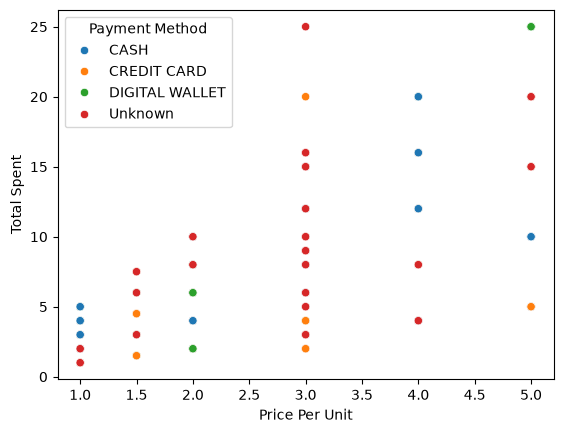

In [183]:
# Price aur Total Spent
sns.scatterplot(data=df, x="Price Per Unit", y="Total Spent", hue="Payment Method")
plt.show()

In [184]:
# remove Unknown locations
analysis_df = df[df["Location"] != "Unknown"]

# vector form for df
vector_matrix = analysis_df.pivot_table(
    index="Location", columns="Item", values="Total Spent", aggfunc="sum"
).fillna(0)

similarity_scores = cosine_similarity(vector_matrix)
similarity_df = pd.DataFrame(
    similarity_scores, index=vector_matrix.index, columns=vector_matrix.index
)
similarity_df

Location,IN-STORE,TAKEAWAY
Location,,
IN-STORE,1.000000,0.997515
TAKEAWAY,0.997515,1.000000


In [185]:
df.to_csv(r"D:\SapphireWork\data\processed\cleaned_transactions.csv", index=False)